# Data Processing for OPM-MEG data - Gardner Things dataset (Pilot for SDBP)
## Data loading, artifact rejeciton, plotting average evoked response across all sensors for all Things images
##### MK 2026

Based on AMP's OPM tutorial

#### Step 1: Load in and inspect the raw data, concatenate all files, and set up events

In [1]:
import mne
# mne.viz.set_3d_backend("notebook")
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import pandas as pd


In [2]:

subject = 'S004' # can make this a loop to batch process future subjects
sample_dir = f'/Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-{subject}'

# grab all of the datafiles in sample_dir, the data directory:
allfiles = []
for file in glob.iglob(os.path.join(sample_dir,'*_raw.fif')):
    allfiles.append(file)
    print(file)

/Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-S004/20260825_105837_sub-S004_file-ThingsPilotRun09_raw.fif
/Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-S004/20260825_105019_sub-S004_file-ThingsPilotRun07_raw.fif
/Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-S004/sub-S004_file-ThingsPilotRun01_raw.fif
/Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-S004/20260825_103412_sub-S004_file-ThingsPilotRun03_raw.fif
/Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-S004/20260825_102956_sub-S004_file-ThingsPilotRun02_raw.fif
/Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-S004/20260825_104244_sub-S004_file-ThingsPilotRun05_raw.fif
/Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-S004/20260825_103829_sub-S004_file-ThingsPilotRun04_raw.fif
/Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-S004/20260825_110653_sub-S004_file-ThingsPilotRun11_raw.fif


In [3]:
## set your subject dir so MNE and FreeSurfer know where to look for anatomy info - do this if doing source localization
# subjects_dir = '/Users/milena/Library/CloudStorage/GoogleDrive-milenak@stanford.edu/My Drive/Koret/_ OPM suite/OPM data processing tutorial/OPM_processing_notebook-main/ANATOMY'

Load in an example dataset and take a look at the "info" structure

In [4]:
thisfile = allfiles[0]
raw = mne.io.read_raw_fif(os.path.join(sample_dir,thisfile),'default', preload=True)
raw.info

Opening raw data file /Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-S004/20260825_105837_sub-S004_file-ThingsPilotRun09_raw.fif...
    Range : 0 ... 237299 =      0.000 ...   237.299 secs
Ready.
Reading 0 ... 237299  =      0.000 ...   237.299 secs...


<Info | 18 non-empty values
 bads: 4 items (L117_bz-s113, L203_bz-s67, L504_bz-s86, L605_bz-s90)
 ch_names: L101_bz-s139, L102_bz-s129, L103_bz-s131, L104_bz-s137, ...
 chs: 143 Magnetometers, 1 Stimulus
 custom_ref_applied: False
 description: {"chassis":{"version":"hedscan-0.11.29- ...
 dig: 6 items (3 Cardinal, 3 HPI)
 experimenter: MK
 file_id: 4 items (dict)
 gantry_angle: 0.0
 highpass: 0.0 Hz
 line_freq: 0.0
 lowpass: 500.0 Hz
 meas_date: 2026-08-25 17:58:37 UTC
 meas_id: 4 items (dict)
 nchan: 144
 proj_id: 0
 proj_name: Things
 projs: []
 sfreq: 1000.0 Hz
 xplotter_layout: None
>

In [5]:
# Concatenate all of the data!

allData = []
for file in allfiles:
    theseData = mne.io.read_raw_fif(file, preload=True)
    # remove bad channel flags in case of inconsistencies between files - remember to remove bad channels later in artifact rejection step
    theseData.info['bads'] = [] 
    allData.append(theseData)

raw = mne.io.concatenate_raws(allData, preload=True, on_mismatch="ignore")

Opening raw data file /Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-S004/20260825_105837_sub-S004_file-ThingsPilotRun09_raw.fif...
    Range : 0 ... 237299 =      0.000 ...   237.299 secs
Ready.
Reading 0 ... 237299  =      0.000 ...   237.299 secs...
Opening raw data file /Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-S004/20260825_105019_sub-S004_file-ThingsPilotRun07_raw.fif...
    Range : 0 ... 238099 =      0.000 ...   238.099 secs
Ready.
Reading 0 ... 238099  =      0.000 ...   238.099 secs...
Opening raw data file /Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-S004/sub-S004_file-ThingsPilotRun01_raw.fif...
    Range : 0 ... 255799 =      0.000 ...   255.799 secs
Ready.
Reading 0 ... 255799  =      0.000 ...   255.799 secs...
Opening raw data file /Users/justin/Desktop/digitalbrain/MEG-OPM/2026-08-25/_RawData/sub-S004/20260825_103412_sub-S004_file-ThingsPilotRun03_raw.fif...
    Range : 0 ... 240399 =      0.000 ...   2

In [6]:
# You can plot the raw data here, but to be honest it is hard to look at it this way and I don't find it super informative so I commented it out
raw.plot()

Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x46ed23bf0) at 0x4612c5d80>

Channels marked as bad:
none


/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()


We can take a deeper look at the events like this, which is useful for more complex paradigms, but lets us see when each trigger was recorded in time, what event ID was read by the aquisition software (called HEDScan), and how many of each trigger were found. Trigger infor: triggers come for every stimulus presentation (every second - and are 1-200 for THINGS images) there should be two special triggers 1023 for catch images (GAN generated mixture of two real images) and 1022 for no stimulus blanks)

Finding events on: di2
2290 events found on stim channel di2
Event IDs: [   2    3    4    5    6    7    8    9   10   11   12   13   14   15
   16   17   18   19   20   21   22   23   24   25   26   27   28   29
   30   31   32   33   34   35   36   37   38   39   40   41   42   43
   44   45   46   47   48   49   50   51   52   53   54   55   56   57
   58   59   60   61   62   63   64   65   66   67   68   69   70   71
   72   73   74   75   76   77   78   79   80   81   82   83   84   85
   86   87   88   89   90   91   92   93   94   95   96   97   98   99
  100  101  102  103  104  105  106  107  108  109  110  111  112  113
  114  115  116  117  118  119  120  121  122  123  124  125  126  127
  128  129  130  131  132  133  134  135  136  137  138  139  140  141
  142  143  144  145  146  147  148  149  150  151  152  153  154  155
  156  157  158  159  160  161  162  163  164  165  166  167  168  169
  170  171  172  173  174  175  176  177  178  179  180  181  182  183
  184

/var/folders/n2/4bqdpl1s6wd9x4l9ll4p03_m0000gq/T/ipykernel_7872/3010388827.py:3: RuntimeWarning: More events than default colors available. You should pass a list of unique colors.
  mne.viz.plot_events(events, sfreq=raw.info["sfreq"], first_samp=raw.first_samp)


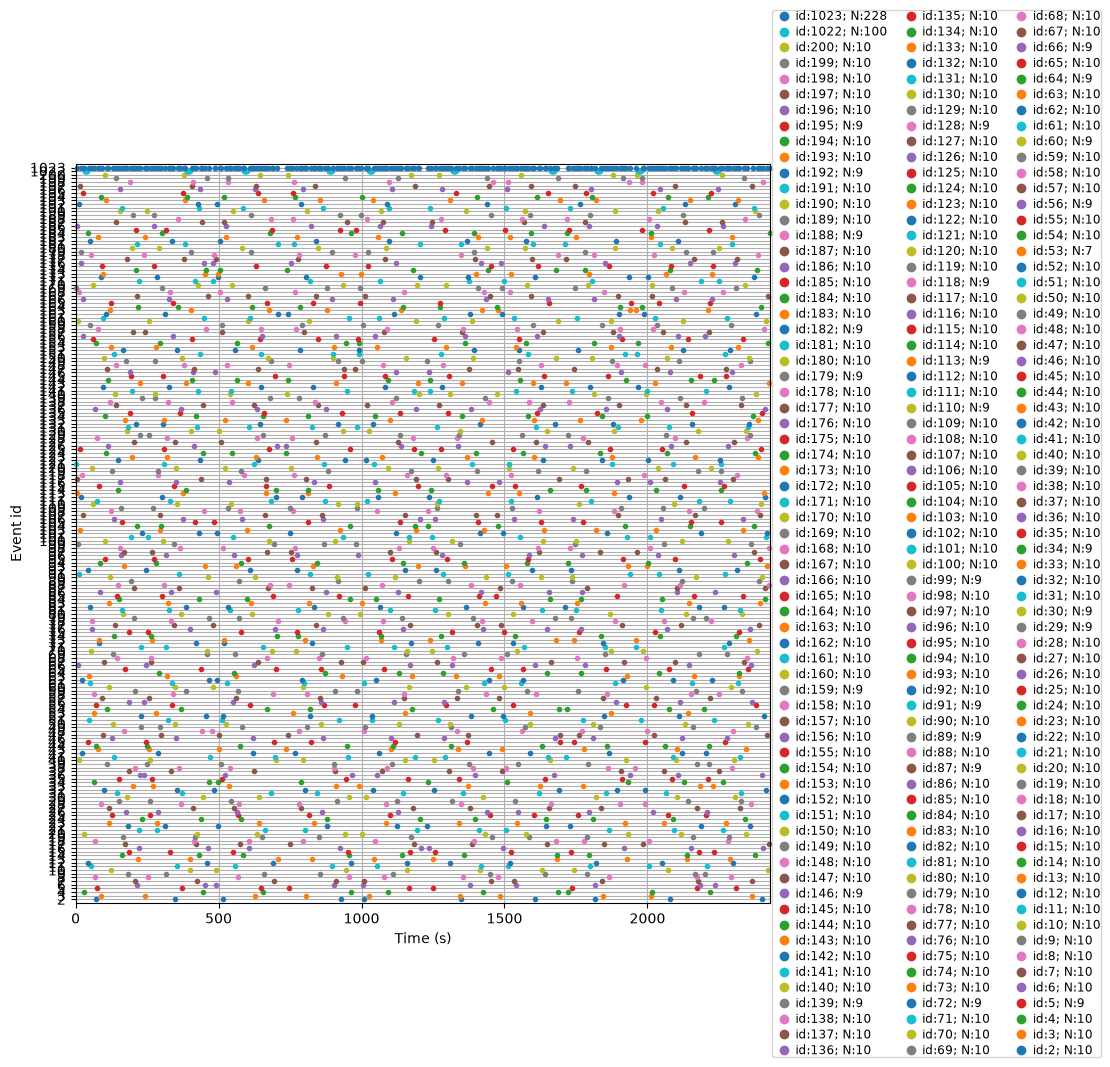

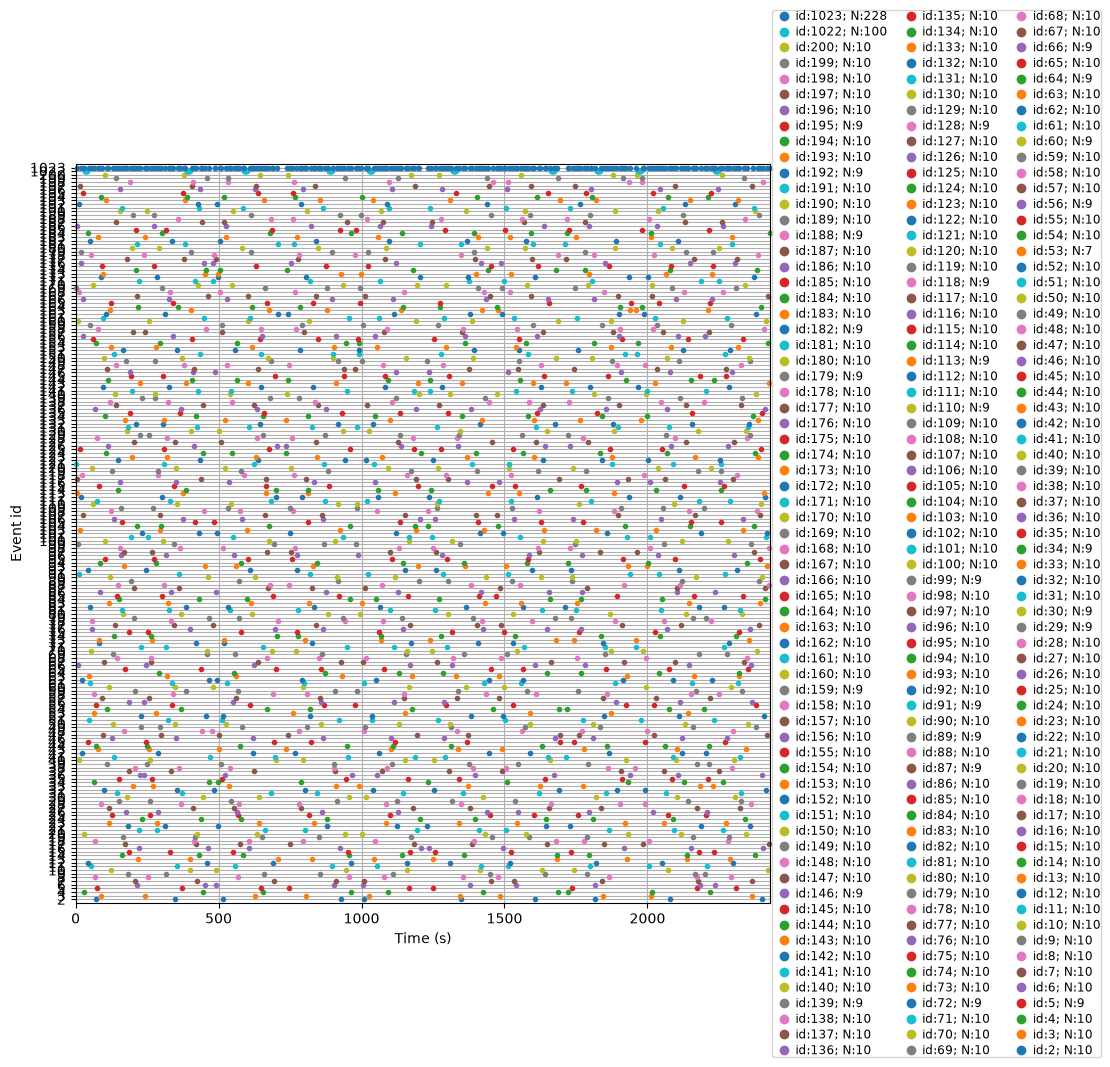

In [7]:
trigger_chan = 'di2' #this is always constant for our OPM system
events = mne.find_events(raw, stim_channel=trigger_chan, shortest_event=1)
mne.viz.plot_events(events, sfreq=raw.info["sfreq"], first_samp=raw.first_samp)

Now we want to make a dataframe to get more specific about what the trigger types mean... We have 3 types, Things images, blanks, and catch trials.

In [8]:
# make into a nice pandas dataframe
events_df = pd.DataFrame()
events_df['code'] = events[:, 2]
for index in range(np.shape(events)[0]):
    code = events_df.at[index,'code']
    if code in range(0,201):
        events_df.at[index,'label']=str("thingsStim")
    elif code==1022:
        events_df.at[index,'label']=str("blank")
    elif code==1023:
        events_df.at[index,'label']=str("catch")

print(events_df)

      code       label
0      169  thingsStim
1      121  thingsStim
2      117  thingsStim
3      113  thingsStim
4     1023       catch
...    ...         ...
2285    98  thingsStim
2286    17  thingsStim
2287    88  thingsStim
2288  1023       catch
2289   184  thingsStim

[2290 rows x 2 columns]


Lets also take a look at the alignment between the sensor positions and the defaced, morphed person's MRI. This is done using the transformation matrix information in "trans_file". Ideally, we will see that all of the sensors are nicely close to the subject's scalp. This code will create a pop-up window where you can explore the 3D view. One thing to note, you may see three blue, red, green spheres hanging out. Normally, these would correspond to the 3 Fiducial positions used by MNE-Python to coregister the sensors to the MRI. But, since we used the YORC method with the 3D scans of the helmet, the positions of these "fiducials" are meaningless, so do not be alarmed if they appear in spots that look misaligned!

In [9]:
# Do this step if you have made the trans file from the raw file
#mne.viz.plot_alignment(
#            raw.info,
#            trans=os.path.join(sample_dir,trans_file),
#            subject=subject,
#            dig=True,
#            meg=["helmet", "sensors"],
#            subjects_dir=subjects_dir,
#            surfaces="head",
#            )

### Step 2: Preprocess the Raw Data
Now that we are all set up, we can preprocess the data! The goal here is to remove any magnetic fields, or "noise", that are not coming from neuronal activity in the brain. First step is to filter the data, advocating for a high-pass set around 0.5 Hz to avoid cutting out any brain activity. Lets look at the frequency spectrum of the data before and after doing this. 

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


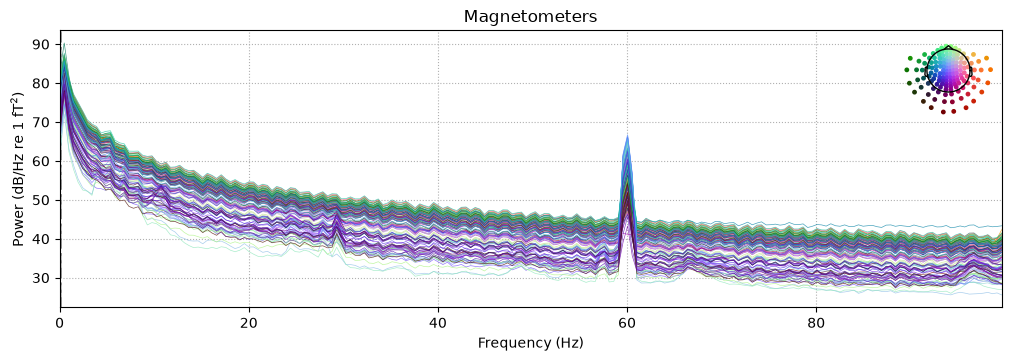

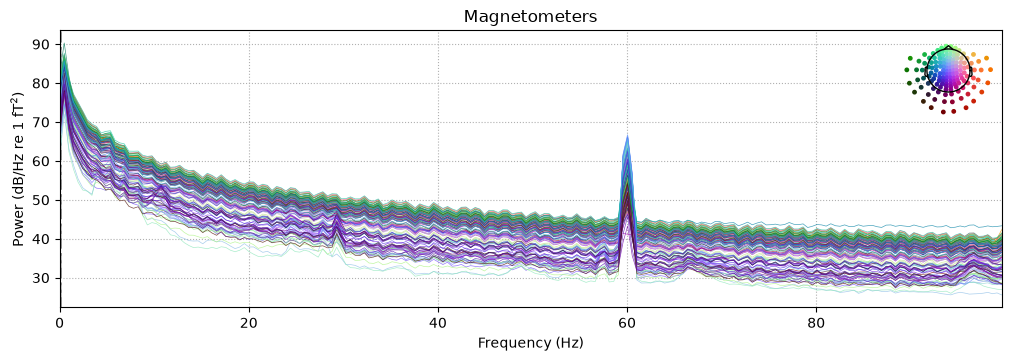

In [10]:
raw.compute_psd(fmax=100).plot(average=False, picks="data", amplitude=False)

We can already see some "bad" channeles that are hovering over all the others with raised noise levels. You can see some are showing up as a dotted line, indicating they have already been marked "bad" in the "info" struture. 

Now, lets filter and take another look

### 2.A Filter and deal with bad channels

Filtering raw data in 10 contiguous segments
Setting up high-pass filter at 0.5 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Filter length: 6601 samples (6.601 s)

Filtering raw data in 10 contiguous segments
Setting up low-pass filter at 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 165 samples (0.165 s)

Filtering raw data in 10 contiguous segments
Setting up band-stop filter from 59 - 61 Hz

FI

/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
/Users/justin/minif

<mne_qt_browser._pg_figure.MNEQtBrowser(0x16b145e90) at 0x479418d40>

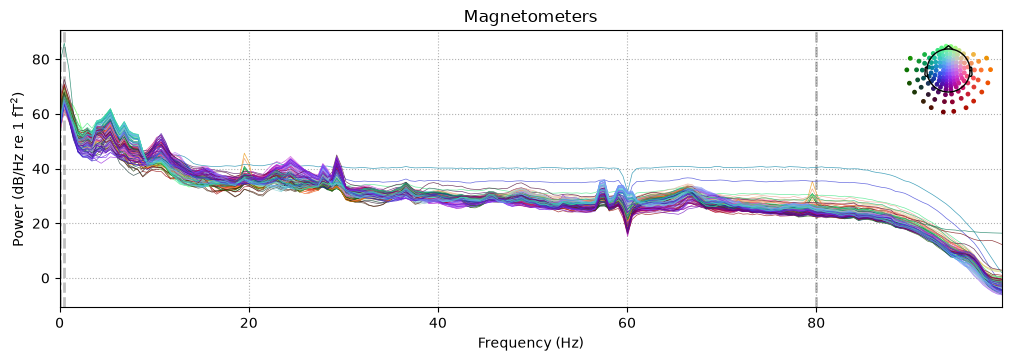

In [11]:
freq_min = 0.5
freq_max = 80
raw.load_data().filter(l_freq=freq_min,h_freq=None)
raw.load_data().filter(l_freq=None,h_freq=freq_max)
meg_picks = mne.pick_types(raw.info, meg=True)
raw.notch_filter(freqs=60, picks=meg_picks)
raw.compute_psd(fmax=100).plot(average=False, picks="data", exclude="bads",amplitude=False)
raw.plot()

The "raw.plot()" will  launch a new window where we can scroll through all channels over all time. channels that are already marked as BAD during data collected will be gray in this plot. If you notice a super noisy channel, you can click on its name, which will turn the channels gray and add the channel to the bads list in the information structure. Or, you can add channels to the bads list. then, you can interpolate the bads, or drop them.

In [12]:
# If you see some bad channels you want to exclude, you can do that here by adding the channel name as the final argument in the following:
raw.info["bads"].extend(['L308_bz-s74','L504_bz-s86','L605_bz-s90'])

If a sensor was "excluded" during data collection, usually because for some reason it didn't turn on, it's position may show up as NaN but it will not be marked as "bad". Lets double check for any cases like this to make sure we mark and drop these sensors.

In [13]:
bads_NaNs=[]
for i in range(0,raw.info["nchan"]):
    ch_pos = raw.info["chs"][i]["loc"][:3]
    if np.isnan(ch_pos).any():
        bads_NaNs.append(raw.info["chs"][i]["ch_name"])
raw.info["bads"].extend(bads_NaNs)

Now that we have found all of our BAd channels and added them to the information strucutre, we have two choices: drop all of the bad channels from our data, or interpolate over them. Lets interpolate, but there is also commented out code below for dropping channels.

In [14]:
 #-- Interpolate bads - set origin to zero in "HEAD" frame
raw.interpolate_bads(origin=[0,0,0],reset_bads=True)

#-- drop bads
# raw.drop_channels(raw.info["bads"])

Setting channel interpolation method to {'meg': 'MNE'}.
Interpolating bad channels.
    Computing dot products for 140 MEG channels...
    Computing cross products for 140 → 3 MEG channels...
    Preparing the mapping matrix...
    Truncating at 109/140 components to omit less than 0.0001 (8.9e-05)


<Raw | 20260825_105837_sub-S004_file-ThingsPilotRun09_raw.fif, 144 x 2434600 (2434.6 s), ~2.61 GiB, data loaded>

### 2.B Detect, annotate eyeblinks for rejection later - NB this isn't doing much in this dataset yet, maybe need to adjust algorithm

We will use two sensors on the forehead in lots R401 and L401 to make an "EOG" channel which is the difference between the two. When the amplitude of this new channel exceeds 5000ft, we will mark this time point and +/-250ms on either side with the annotation "BAD_blink". Note that for later functions using "reject by annotation" when we make epochs, we must label the annotations we want to reject with the prefix "BAD-" for it to be rejected. You can use annotations for anything you want, so sometimes you might not want to use them for rejection and can then not use the prefix "BAD-". This method is based on the method in the published FLUX Pipeline here: https://github.com/FLUX-pipeline/FieldLine/blob/main/Annotation%20of%20artefacts.ipynb

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Creating RawArray with float64 data, n_channels=1, n_times=2434600
    Range : 0 ... 2434599 =      0.000 ...  2434.599 secs
Ready.
Using EOG channel: EOG
EOG channel index for this subject is: [144]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel EOG for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10000 samples (10.000 s)

Now detecting blinks and generat

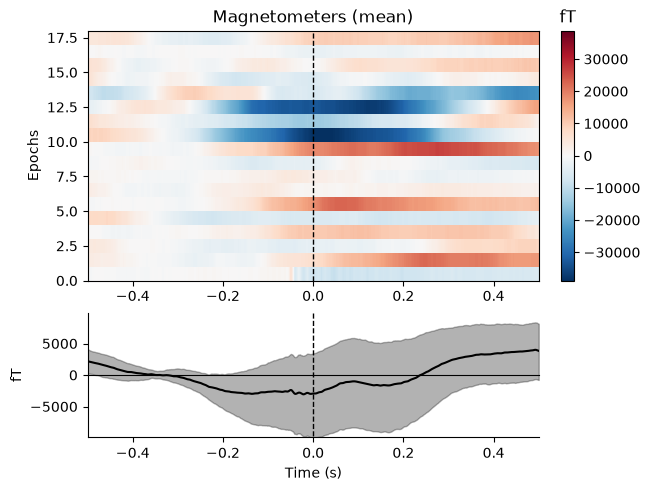

No projector specified for this dataset. Please consider the method self.add_proj.


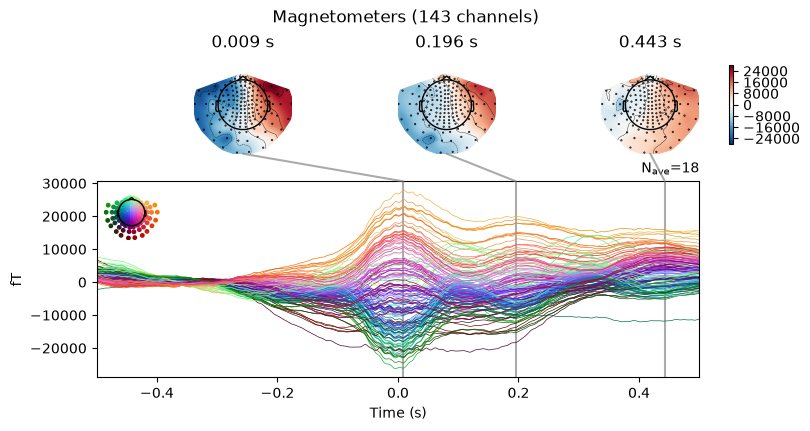

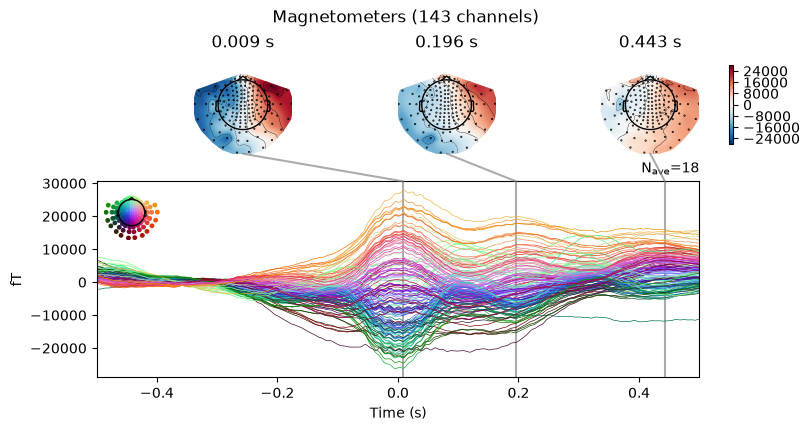

In [15]:
# extract data from two frontal OPM sensors
ch1_data = raw.copy().pick_channels(['R401_bz-s22']).get_data()[0] 
ch2_data = raw.copy().pick_channels(['L401_bz-s92']).get_data()[0] 
# differential signal (Left - Right)
occ_signal = ch1_data - ch2_data
# create new channel called EOG
sfreq = raw.info['sfreq']
new_ch_name = 'EOG' 
info_new = mne.create_info([new_ch_name], sfreq=sfreq, ch_types=['eog'])

# Load the occ_signal data to the newly created channel
raw_eog = mne.io.RawArray(occ_signal[np.newaxis, :], info_new)
# Add the new EOG channel in the Raw object
raw.add_channels([raw_eog], force_update_info=True)

# now find EOG events
eog_events = mne.preprocessing.find_eog_events(raw, ch_name='EOG')
n_blinks = len(eog_events)
# check that they do look like blinks and how many
eog_epochs = mne.preprocessing.create_eog_epochs(raw, baseline=(-0.5, -0.2))
eog_epochs.plot_image(combine="mean")
eog_epochs.average().plot_joint()

The topography of the peak eyeblink epochs does indeed look like an eyeblink! and the channels with the highest amplitude in the evoked plot are 'R401_bz-s22' and 'L401_bz-s92', so it seems very reasonable that we use these two channels to look for and define blinks. The evoked plot is averaged over 47 epochs, so 47 eyeblink events were found. Lets now annotate and add these to our information structure. We will reject them in a lter step when we create our epochs.

In [16]:
# annotate +/-250ms around blink as "bad"
onset = eog_events[:, 0] / raw.info['sfreq'] - 0.25
duration = np.repeat(0.5, n_blinks)
description = ['BAD-blink'] * n_blinks
orig_time = raw.info['meas_date']
annotations_blink = mne.Annotations(onset, duration, description, orig_time)
# add annotations to RAW
raw.set_annotations(annotations_blink)
# launch a plot to look at all the eyeblinks we annotated
raw.plot(events=eog_events)

Channels marked as bad:
none


/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()
/Users/justin/miniforge3/envs/pgl_mne/lib/python3.12/site-packages/mne_qt_browser/_utils.py:36: RuntimeWarning: libpyside: Failed to disconnect (None) from signal "triggered()".
  sig.disconnect()


<mne_qt_browser._pg_figure.MNEQtBrowser(0x46e751de0) at 0x3b7e2a680>

### 2. C artifact rejection using SSS

From here, there are lots of different choices we can make, but I will suggest using Foster's inverse with Signal Space Separation (SSS) method. It is very low assumption and represents the internal data as a series of spatial components while separating out any fields coming from outside the brain. The biggest first step is to ensure that bad channels are marked as bad and are dropped from the SSS process to avoid spatial "mixing" of the noise with the brain signals. There are many parameter choices for us to pass to the function, but I have kept standard ones or changed ones to fit best with OPMs. For more details and examples on SSS, see this tutorial: https://mne.tools/stable/auto_tutorials/preprocessing/60_maxwell_filtering_sss.html

You can also do HFC, which works by a similar concept, and can be found here: https://mne.tools/stable/auto_tutorials/preprocessing/80_opm_processing.html#denoising-regressing-via-homogeneous-field-correction

In [17]:
assert raw.info["bads"] == [] # double check bads were dropped or interpolated
raw_sss = mne.preprocessing.maxwell_filter(raw,
                                           origin=(0., 0., 0.),
                                           int_order=8, 
                                           ext_order=3, 
                                           calibration=None, 
                                           coord_frame='meg', 
                                           regularize='in', 
                                           ignore_ref=True, 
                                           bad_condition='error', 
                                           mag_scale=100.0, 
                                           extended_proj=(), 
                                           verbose=None)

Maxwell filtering raw data
    No bad MEG channels
    Processing 0 gradiometers and 143 magnetometers
    Using origin 0.0, 0.0, 0.0 mm in the meg frame (0.0, 0.0, 0.0 mm in the head frame)
    Using loaded raw data
        Using 88/95 harmonic components for    0.000  (73/80 in, 15/15 out)
    Processing  243 data chunks of (at least) 10.0 s with 0.0 s overlap and boxcar windowing
    The final 4.6 s will be lumped into the final window
        Using 88/95 harmonic components for    0.000  (73/80 in, 15/15 out)
[done]


Success! Notice the line "Using 91/95 harmonic components". 95 components are the 80 internal spatial components from setting "int_order=8" plus 15 external components from "out_order=3", then some regularization is happening to improve stability. These are recommended from the SSS paper for Cryo-MEG. When adapting to OPMs, the main issue is to ensure that the number of sensors is larger than the number of harmonic spatial components. For us, 144>95, so we are good! But other OPM systems with less channels usually use Homogenous Field Correction (HFC), which is sort of like doing SSS with "int_order=1". A tutorial for HFC on an Triaxial QuSpin OPM system can be found here: https://mne.tools/stable/auto_tutorials/preprocessing/80_opm_processing.html#denoising-regressing-via-homogeneous-field-correction

for now, let's just use the simple preprocessed data with only filtering and bad channel rejection. If you want to see the effects of SSS, uncomment and run the line below.

In [18]:
# raw = raw_sss

### Step 3: Create Epochs based on Events Timing and Evoked Averages
Now, we use our events to splice up our continuous raw data into sections with brain activity and average over the brain's response to each occurance of the same stimuli. Which, for us here, is 200 Epochs of the same brain response, creating one Evoked average. We'll still use our Pandas dataframe as an example, so this code will work for cases where you have more complex stimuli.

Adding metadata with 2 columns
2290 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2290 events and 1001 original time points ...
3 bad epochs dropped
No projector specified for this dataset. Please consider the method self.add_proj.


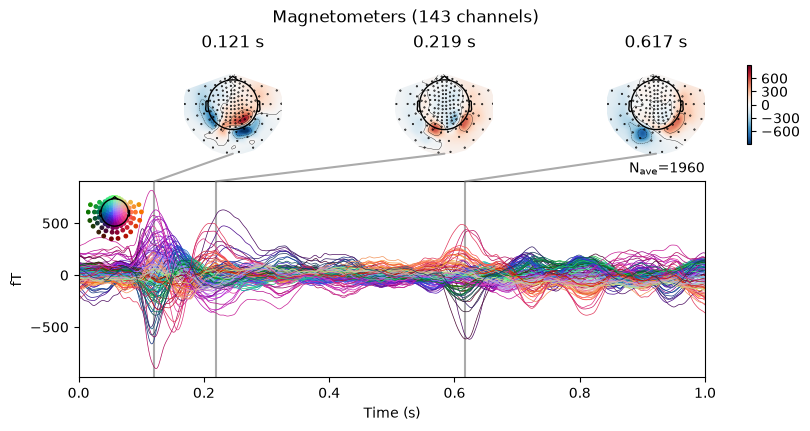

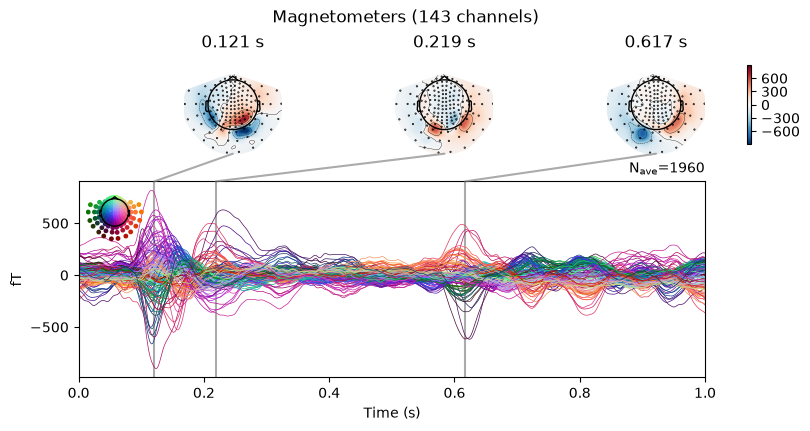

In [19]:
tmin = -0.0  # start of each epoch
tmax =  1.0 # end of each epoch
epochs = mne.Epochs(raw, events,
            tmin=tmin,tmax=tmax,
            baseline=None,
            reject=None,
            preload=True,
            metadata=events_df) # give it our data frame

#specify plotting arguements
ts_args = ts_args = dict(time_unit="s") # can specify limits as ylim=dict(mag=(-400, 400)))
topomap_args = dict(time_unit="s") # you can pass other args here, like 'vmin', 'vmax', 'cmap', etc.

# create an evoked for each "condition" -- which is just each "tone" here -- and plot
#make evoked of just images
evoked = epochs['label == "thingsStim"'].average()
evoked.plot_joint()

Largest-response magnetometer: L213_bz-s115
RMS amplitude: 2.44e-13
Peak latency: 0.231 s
Need more than one channel to make topography for mag. Disabling interactivity.


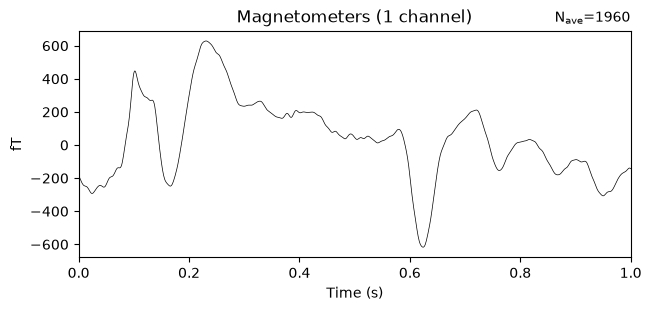

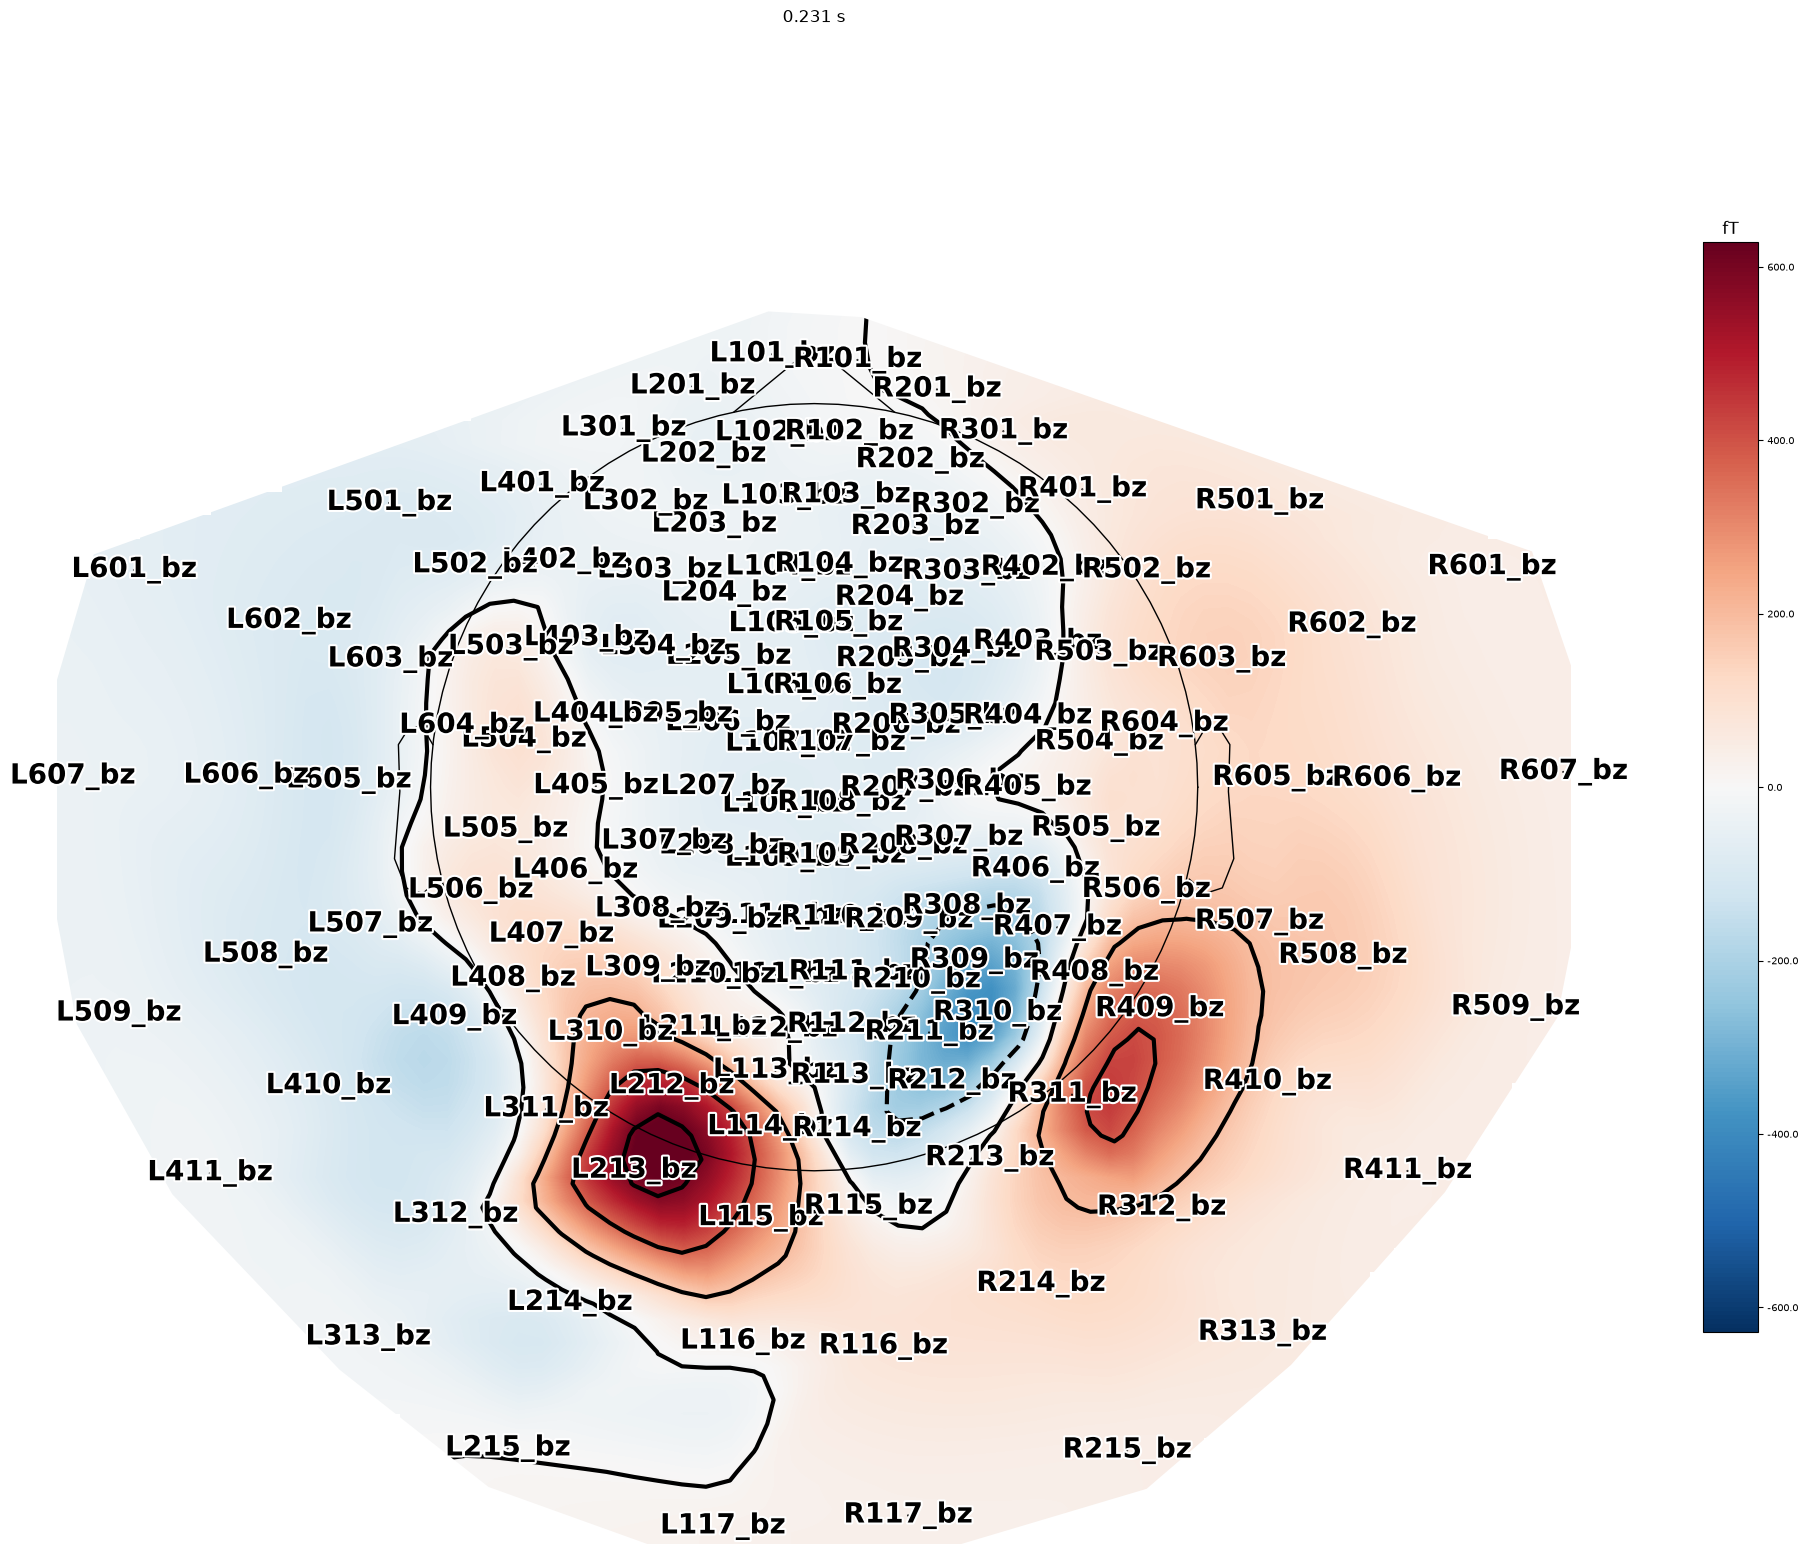

In [20]:
# Get the evoked response for thingsStim
evoked = epochs['label == "thingsStim"'].average()

# --------------------------------------------------
# 1. Find magnetometer with the largest response
# --------------------------------------------------

# RMS response across the epoch for each magnetometer
rms = np.sqrt(np.mean(evoked.data ** 2, axis=1))

peak_channel_idx = np.argmax(rms)
peak_channel = evoked.ch_names[peak_channel_idx]

#peak_channel = [ch for ch in evoked.ch_names if 'R311' in ch][0]

print(f"Largest-response magnetometer: {peak_channel}")
print(f"RMS amplitude: {rms[peak_channel_idx]:.2e}")


# --------------------------------------------------
# 2. Find the time of the largest response
# --------------------------------------------------

peak_time_idx = np.argmax(np.abs(evoked.data[peak_channel_idx]))
peak_time = evoked.times[peak_time_idx]

print(f"Peak latency: {peak_time:.3f} s")


# --------------------------------------------------
# 3. Plot the response at that magnetometer
# --------------------------------------------------

#peak_channel = 'R311_bz-s22'  # Replace with the actual channel name you want to plot
evoked.plot(
    picks=[peak_channel],
    spatial_colors=False
)


# --------------------------------------------------
# 4. Plot MEG sensor map at peak latency
# --------------------------------------------------

import matplotlib.patheffects as path_effects

fig = evoked.plot_topomap(
    times=peak_time,
    ch_type='mag',
    sensors=True,
    show_names=True,
    colorbar=True,
    size=12,
    show=False
)

# Make sensor labels large, bold, and visually on top
for ax in fig.axes:
    for text in ax.texts:
        text.set_fontsize(20)       # increase font size
        text.set_fontweight('bold')
        text.set_color('black')
        text.set_zorder(1000)       # put text above everything else

        # White outline around black text
        text.set_path_effects([
            path_effects.Stroke(
                linewidth=3,
                foreground='white'
            ),
            path_effects.Normal()
        ])

plt.show()

In [21]:
print("Conditions and number of repeats:\n")

for condition, count in epochs.metadata['label'].value_counts().items():
    print(f"{condition}: {count}")


Conditions and number of repeats:

thingsStim: 1960
catch: 227
blank: 100


In [22]:
trigger_chan = 'di2' #this is always constant for our OPM system
events = mne.find_events(raw, stim_channel=trigger_chan, shortest_event=1)

# The 202 conditions we care about
condition_numbers = list(range(1, 201)) + [1022, 1023]

# Create epochs for all 202 conditions
event_id = {str(n): n for n in condition_numbers}

epochs_conditions = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=0.0,
    tmax=1.0,
    baseline=None,
    reject=None,
    preload=True,
    on_missing='ignore'
)

# Print summary
print("Condition | Repeats | Epoch numbers")
print("-" * 70)

for condition in condition_numbers:

    # Find where this condition occurs in the ORIGINAL events array
    event_indices = np.where(events[:, 2] == condition)[0]

    print(
        f"{condition:9d} | "
        f"{len(event_indices):7d} | "
        f"{event_indices.tolist()}"
    )


Finding events on: di2
2290 events found on stim channel di2
Event IDs: [   2    3    4    5    6    7    8    9   10   11   12   13   14   15
   16   17   18   19   20   21   22   23   24   25   26   27   28   29
   30   31   32   33   34   35   36   37   38   39   40   41   42   43
   44   45   46   47   48   49   50   51   52   53   54   55   56   57
   58   59   60   61   62   63   64   65   66   67   68   69   70   71
   72   73   74   75   76   77   78   79   80   81   82   83   84   85
   86   87   88   89   90   91   92   93   94   95   96   97   98   99
  100  101  102  103  104  105  106  107  108  109  110  111  112  113
  114  115  116  117  118  119  120  121  122  123  124  125  126  127
  128  129  130  131  132  133  134  135  136  137  138  139  140  141
  142  143  144  145  146  147  148  149  150  151  152  153  154  155
  156  157  158  159  160  161  162  163  164  165  166  167  168  169
  170  171  172  173  174  175  176  177  178  179  180  181  182  183
  184

In [ ]:
# ============================================================
# DOWNSAMPLE EPOCHS TO 200 HZ
# ============================================================
# Conditions to include
conditions = list(range(2, 201))

targetSfreq = 200.0

# Check the original sampling rate using the first requested condition
firstEpochs = epochs_conditions[str(conditions[0])]
originalSfreq = firstEpochs.info["sfreq"]

if originalSfreq < targetSfreq:
    raise ValueError(
        f"Original sampling rate is {originalSfreq} Hz, which is below "
        f"the requested target of {targetSfreq} Hz. Cannot downsample."
    )

# Store resampled copies so the original epochs_conditions remain unchanged
epochsConditions200Hz = {}

pbar = tqdm(conditions, desc="Downsampling to 200 Hz", unit="cond")

for condition in pbar:
    epochsCond = epochs_conditions[str(condition)].copy()

    # MNE's resample applies anti-alias filtering as part of resampling.
    if not np.isclose(epochsCond.info["sfreq"], targetSfreq):
        epochsCond.resample(
            sfreq=targetSfreq,
            npad="auto",
            verbose=False,
        )

    epochsConditions200Hz[str(condition)] = epochsCond

pbar.close()

# Time vector corresponding to all subsequently extracted data
times = epochsConditions200Hz[str(conditions[0])].times

print(
    f"Downsampled from {originalSfreq:.1f} Hz "
    f"to {targetSfreq:.1f} Hz."
)

Downsampling to 200 Hz:   0%|          | 0/199 [00:00<?, ?cond/s]

Downsampled from 1000.0 Hz to 200.0 Hz.


In [94]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# ============================================================
# SETTINGS
# ============================================================

# Specify the OPM magnetometer you want to analyze
channel = "R311_bz-s45"
#channel = peak_channel

# Conditions to include
conditions = list(range(2, 201))


# ============================================================
# GET DATA FOR EACH CONDITION
# ============================================================

condition_data = {}
condition_means = {}
n_reps_per_condition = {}

t0 = time.time()
pbar = tqdm(conditions, desc="Extracting condition data", unit="cond")

for condition in pbar:

    # Get epochs for this condition
    epochs_cond = epochsConditions200Hz[str(condition)]
    #epochs_cond = epochs_conditions[str(condition)]

    # Pick the specified channel
    data = epochs_cond.get_data(picks=[channel])

    # Remove the channel dimension
    # Shape: (repeats, time)
    data = data[:, 0, :]

    # Store individual trials
    condition_data[condition] = data
    n_reps_per_condition[condition] = data.shape[0]

    # Average across repeats
    # Shape: (time,)
    condition_means[condition] = np.mean(data, axis=0)

    elapsed = time.time() - t0
    pbar.set_postfix(elapsed=f"{elapsed:.1f}s")

pbar.close()


# ============================================================
# 1. NOISE: SINGLE-TRIAL WITHIN-CONDITION VARIANCE / SD
#
# For each condition, calculate variance across repeats at each
# time point. Average variances across conditions, then take
# the square root to obtain the typical single-trial noise SD.
# ============================================================

noiseVarByCondition = []

for condition in tqdm(conditions, desc="Computing noise", unit="cond"):

    # Shape: (repeats, time)
    data = condition_data[condition]

    # Shape: (time,)
    # Sample variance across repeats at each time point
    noiseVar = np.var(data, axis=0, ddof=1)

    noiseVarByCondition.append(noiseVar)

# Shape: (conditions, time)
noiseVarByCondition = np.asarray(noiseVarByCondition)

# Shape: (time,)
# Typical single-trial noise variance and SD across conditions
noiseVar = np.mean(noiseVarByCondition, axis=0)
noiseSTD = np.sqrt(noiseVar)


# ============================================================
# 2. SIGNAL: NOISE-CORRECTED VARIANCE / SD ACROSS CONDITIONS
#
# Variance of condition means includes:
#
#   observedVar = signalVar + residualNoiseVar
#
# For condition c, the residual noise variance in its mean is:
#
#   noiseVarByCondition[c] / nReps[c]
#
# Subtract the average residual noise variance to estimate
# the true signal variance across conditions.
# ============================================================

# Shape: (conditions, time)
conditionMeansArray = np.asarray([
    condition_means[condition]
    for condition in conditions
])

# Shape: (conditions,)
repsArray = np.asarray([
    n_reps_per_condition[condition]
    for condition in conditions
])

# Shape: (time,)
# Sample variance across condition means
observedVar = np.var(conditionMeansArray, axis=0, ddof=1)

# Shape: (time,)
# Mean residual noise variance remaining in the condition means.
# [:, np.newaxis] changes repsArray from (conditions,) to
# (conditions, 1), allowing division across all time points.
residualNoiseVar = np.mean(
    noiseVarByCondition / repsArray[:, np.newaxis],
    axis=0,
)

# Shape: (time,)
# Noise-corrected signal variance.
# Clip at zero because finite-sample estimation can otherwise
# produce small negative values.
signalVar = np.maximum(observedVar - residualNoiseVar, 0)

# Shape: (time,)
signalSTD = np.sqrt(signalVar)


# ============================================================
# 3. NOISE-CORRECTED SNR
#
# NCSNR = signal SD / single-trial noise SD
# ============================================================

ncsnr = np.divide(
    signalSTD,
    noiseSTD,
    out=np.full_like(signalSTD, np.nan, dtype=float),
    where=noiseSTD > 0,
)


# ============================================================
# 3b. GRAND MEAN RESPONSE (for top plot)
# ============================================================

grandMean = np.mean(conditionMeansArray, axis=0)



Extracting condition data:   0%|          | 0/199 [00:00<?, ?cond/s]

Computing noise:   0%|          | 0/199 [00:00<?, ?cond/s]

ValueError: x and y must have same first dimension, but have shapes (200,) and (1001,)

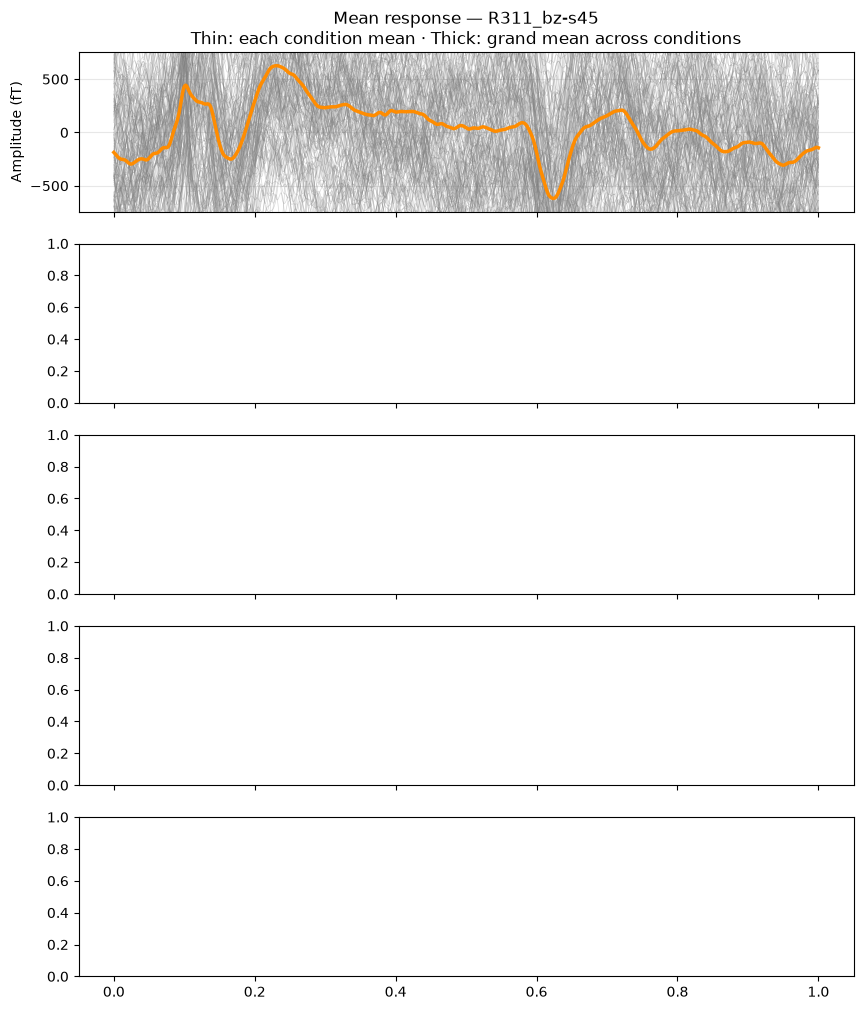

In [ ]:

# ============================================================
# 4. PLOT
# ============================================================

timesOriginal = epochs_conditions[str(conditions[0])].times
times = epochsConditions200Hz[str(conditions[0])].times

# Unit conversion: MNE returns data in Tesla (SI units).
# Amplitude scales by 1e15 to get femtotesla (fT).
T_TO_FT = 1e15

condition_means_array_fT = condition_means_array * T_TO_FT
grand_mean_fT = grand_mean * T_TO_FT

noise_by_condition_fT2 = noise_by_condition * T_TO_FT
noiseSTD_fT2 = noiseSTD * T_TO_FT
signalSTD_fT2 = signalSTD * T_TO_FT

fig, axes = plt.subplots(
    5, 1,
    figsize=(10, 12),
    sharex=True
)

# --- Mean response across conditions ---
for condition_mean in condition_means_array_fT:
    axes[0].plot(
        timesOriginal,
        condition_mean,
        color="gray",
        linewidth=0.5,
        alpha=0.3
    )
axes[0].plot(
    timesOriginal,
    grand_mean_fT,
    color="darkorange",
    linewidth=2.5
)

# Scale y-axis to the grand mean, not the individual traces
grand_mean_range = grand_mean_fT.max() - grand_mean_fT.min()
pad = 0.1 * grand_mean_range if grand_mean_range > 0 else 0.1 * abs(grand_mean_fT.max())
axes[0].set_ylim(grand_mean_fT.min() - pad, grand_mean_fT.max() + pad)

axes[0].set_ylabel("Amplitude (fT)")
axes[0].set_title(
    f"Mean response — {channel}\n"
    "Thin: each condition mean · Thick: grand mean across conditions"
)
axes[0].grid(alpha=0.3)

# --- Noise ---
for noise_trace in noise_by_condition_fT2:
    axes[1].plot(
        timesOriginal,
        noise_trace,
        color="gray",
        linewidth=0.5,
        alpha=0.3
    )
axes[1].plot(
    timesOriginal,
    noiseSTD_fT2,
    color="steelblue",
    linewidth=2.5
)

# Scale y-axis to the averaged noise curve, not the individual traces
noise_range = noiseSTD_fT2.max() - noiseSTD_fT2.min()
pad = 0.1 * noise_range if noise_range > 0 else 0.1 * abs(noiseSTD_fT2.max())
axes[1].set_ylim(max(0, noiseSTD_fT2.min() - pad), noiseSTD_fT2.max() + pad)

axes[1].set_ylabel("Noise STD (fT)")
axes[1].set_title(
    "Noise\n"
    "Thin: STD across repeats per condition · Thick: averaged across conditions"
)
axes[1].grid(alpha=0.3)

# --- Signal ---
axes[2].plot(
    times,
    signalSTD_fT2,
    color="firebrick",
    linewidth=2
)
axes[2].set_ylabel("Signal STD (fT)")
axes[2].set_title(
    "Signal (bias-corrected)\n"
    f"STD across condition averages, minus noise/median_n_reps (n={median_n_reps:.0f})"
)
axes[2].grid(alpha=0.3)

# --- SNR ---
axes[3].plot(
    times,
    ncsnr,
    color="black",
    linewidth=2
)
axes[3].set_ylabel(f"noise ceiling SNR\n(sigma_signal / sigma_noise)")
axes[3].set_xlabel("Time (s)")
axes[3].set_title("Noise ceiling signal-to-noise ratio (ncsnr)")
axes[3].grid(alpha=0.3)

# --- Noise Ceiling ---
# Noise ceiling (% variance explained) if you averaged n=12 trials
n_trials = 12
noise_ceiling = 100 * ncsnr**2 / (ncsnr**2 + 1 / n_trials)

axes[4].plot(
    times,
    noise_ceiling,
    color="black",
    linewidth=2
)
axes[4].set_ylabel(f"Noise ceiling (percent)")
axes[4].set_xlabel("Time (s)")
axes[4].set_title(f"Noise ceiling for n={n_trials} trials")
axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Yay! Here we can check some things. One: theres clealry a peak response, and there's not any major drifts happening as the baseline before 0.00 is very flat. Two: the topography looks like an auditory response with the blue/red dipoles centered around the auditory cortex of both hemispheres. Very good. you can do lots of things from here, like compare accross conditions, and we didn't need any subject MRI data.

We can also take a closer look at our eyeblinks using the "drop log" inside of the epochs structure, which will tell us how many epochs were dropped per evoked condition, and which reason. Since we only have one condition (one tone frequency) and one annotation reason (bad_blink), the results will be not so useful, but if you have more conditions and/or other drop reasons, this is a helpful step. 

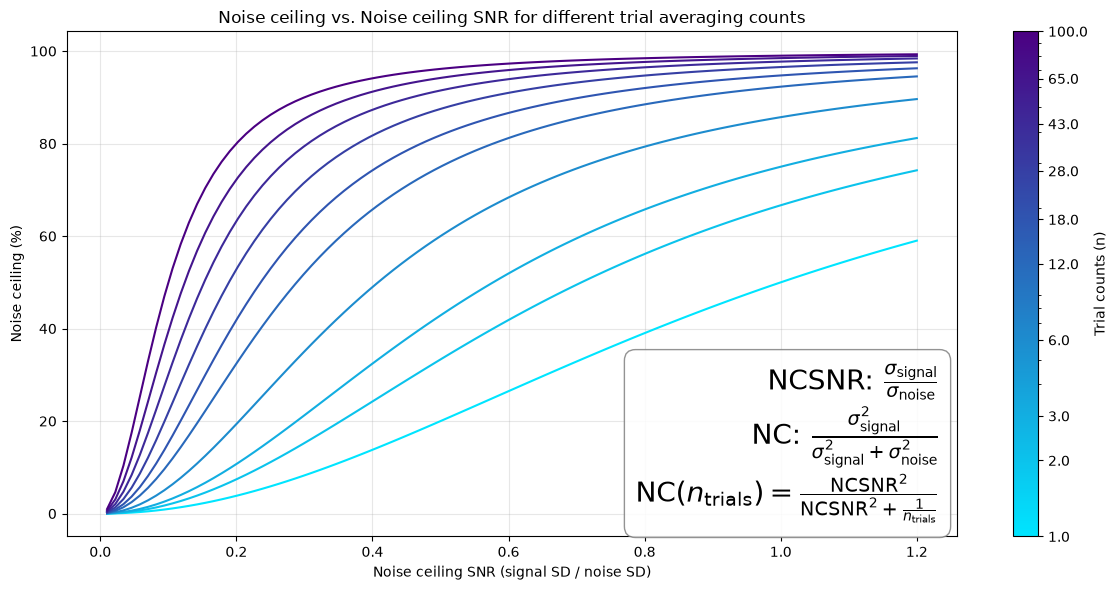

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

ncsnr = np.linspace(0.01, 1.2, 100)

nValues = np.unique(
        np.concatenate([
            np.geomspace(1, 12, 5),
            np.geomspace(12, 100, 6)[1:],
        ])
)
n_values = np.round(np.concatenate([np.geomspace(1, 12, 5), np.geomspace(12, 100, 6)[1:]]))
n_min, n_max = min(n_values), max(n_values)

# Custom cyan -> deep purple colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    "cyan_purple", ["#00e5ff", "#4b0082"]
)

# Log-scaled normalization instead of linear
norm = mcolors.LogNorm(vmin=n_min, vmax=n_max)

f, ax = plt.subplots(figsize=(12, 6))

for nTrials in n_values:
    noise_ceiling = 100 * ncsnr**2 / (ncsnr**2 + 1 / nTrials)
    ax.plot(ncsnr, noise_ceiling, color=cmap(norm(nTrials)), linewidth=1.5)

ax.set_xlabel("Noise ceiling SNR (signal SD / noise SD)")
ax.set_ylabel("Noise ceiling (%)")
ax.set_title("Noise ceiling vs. Noise ceiling SNR for different trial averaging counts")
ax.grid(alpha=0.3)

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = f.colorbar(sm, ax=ax)
cbar.set_label("Trial counts (n)")

# Explicit plain-number ticks instead of exponential notation
tick_values = n_values
cbar.set_ticks(tick_values)
cbar.set_ticklabels([str(v) for v in tick_values])

equations = (
    r"NCSNR: "
    r"$\frac{\sigma_{\mathrm{signal}}}{\sigma_{\mathrm{noise}}}$"
    "\n"
    r"NC: "
    r"$\frac{\sigma_{\mathrm{signal}}^{2}}"
    r"{\sigma_{\mathrm{signal}}^{2} + \sigma_{\mathrm{noise}}^{2}}$"
    "\n"
    r"$\mathrm{NC}(n_{\mathrm{trials}}) = "
    r"\frac{\mathrm{NCSNR}^{2}}"
    r"{\mathrm{NCSNR}^{2} + \frac{1}{n_{\mathrm{trials}}}}$")

ax.text(
    0.98, 0.02,              # Lower-right corner in axes coordinates
    equations,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=20,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="gray",
        alpha=0.85,
    ),
)
plt.tight_layout()
plt.show()


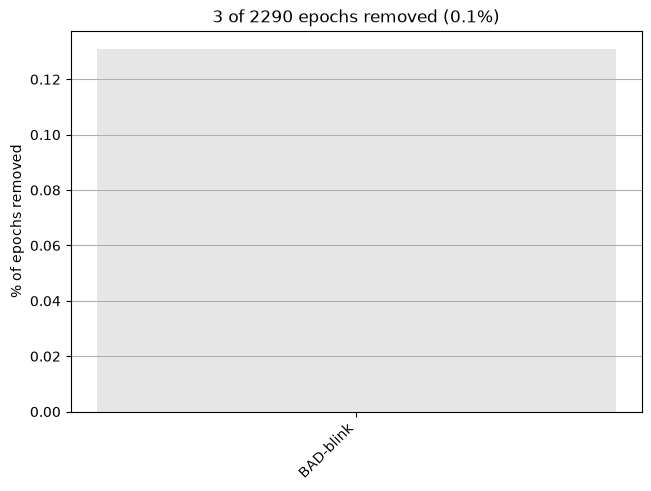

KeyError: 'condition'

In [24]:
epochs.plot_drop_log()
original_metadata = events_df.copy() 
# MNE stores drop reasons as a list of tuples in epochs.drop_log
is_eog_drop = ['BAD-blink' in reason for reason in epochs.drop_log]
original_metadata['dropped_EOG'] = is_eog_drop
eog_drops_per_condition = original_metadata[original_metadata['dropped_EOG']].groupby('condition').size()
print(eog_drops_per_condition)